# Final Model Small

In [ ]:
import os
import tensorflow as tf
import tf_keras as keras

# Install the packages without pinning tf_keras to 2.15.0.
# Pip will resolve the best legacy Keras for your current TF version.
!pip install --quiet tf_keras quantizeml cnn2snn akida

# Force legacy Keras BEFORE importing TensorFlow
os.environ["TF_USE_LEGACY_KERAS"] = "1"

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras module: {keras.__name__}")
print(f"Keras version: {keras.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.1/179.1 kB 6.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.4/83.4 kB 7.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.3/129.3 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.9/660.9 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━

## Dataset load

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
import tf_keras
from tf_keras.models import Sequential
from tf_keras.layers import Conv2D, Flatten, Dense, ReLU, Input, Dropout, BatchNormalization, ZeroPadding2D
from tf_keras.optimizers import Adam
from tf_keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import os
import matplotlib.pyplot as plt
from quantizeml import load_model
from quantizeml.models import quantize, QuantizationParams
from quantizeml.models.quantize import dump_config
from cnn2snn import set_akida_version, AkidaVersion
import cnn2snn
from cnn2snn import convert
import akida



In [ ]:
# Path to the dataset and labels
dataset_path = 'X_watch_20Hz_scaled_small.npy'
labels_path = 'y_watch_labels_small.npy'

try:
    X_data = np.load(dataset_path)
    y_labels = np.load(labels_path).astype(np.int32)

    print(f"Dataset loaded successfully from: {dataset_path}")
    print(f"Labels loaded successfully from: {labels_path}")

    print(f"\nX_data shape: {X_data.shape}")
    print(f"y_labels shape: {y_labels.shape}, dtype: {y_labels.dtype}")

except FileNotFoundError:
    print(f"Error: One or both files were not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Dataset loaded successfully from: /content/drive/MyDrive/Project MLA - On Edge Motion Recognition/processed_data/X_watch_20Hz_scaled_small.npy
Labels loaded successfully from: /content/drive/MyDrive/Project MLA - On Edge Motion Recognition/processed_data/y_watch_labels_small.npy

X_data shape: (64687, 40, 6)
y_labels shape: (64687,), dtype: int32


### Dataset Split

In [ ]:
def split_and_save_dataset(X, y, train_size=0.7, val_size=0.15, test_size=0.15, random_state=42):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, train_size=train_size, random_state=random_state, stratify=y
    )

    relative_val_size = val_size / (val_size + test_size)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, train_size=relative_val_size, random_state=random_state, stratify=y_temp
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

In [ ]:
X_train, X_val, X_test, y_train, y_val, y_test = split_and_save_dataset(X_data, y_labels, train_size=0.7, val_size=0.15, test_size=0.15)

# Remap the labels into a continuous range [0, N-1]
unique_labels = np.unique(y_train)
label_mapping = {old_label: new_label for new_label, old_label in enumerate(unique_labels)}

def apply_mapping(labels, mapping):
    return np.array([mapping[label] for label in labels], dtype=np.int32)

y_train = apply_mapping(y_train, label_mapping)
y_val = apply_mapping(y_val, label_mapping)
y_test = apply_mapping(y_test, label_mapping)

num_classes = len(unique_labels)
    
print(f"Number of unique classes detected: {num_classes}")
print(f"Applied mapping: {label_mapping}")
print(f"X_train dimensions: {X_train.shape}, y_train: {y_train.shape}")

Numero di classi uniche rilevate: 7
Mapping applicato: {np.int32(5): 0, np.int32(6): 1, np.int32(13): 2, np.int32(14): 3, np.int32(15): 4, np.int32(16): 5, np.int32(17): 6}
Dimensioni X_train: (45280, 40, 6), y_train: (45280,)


In [ ]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(45280, 40, 6)
(9703, 40, 6)
(9704, 40, 6)
(45280,)
(9703,)
(9704,)


In [ ]:
X_train_reshaped = X_train.reshape(-1, 40, 6, 1)
X_val_reshaped = X_val.reshape(-1, 40, 6, 1)
X_test_reshaped = X_test.reshape(-1, 40, 6, 1)

# 41x9 for hardware symmetric padding
pad_config = ((0,0), (0,1), (1,2), (0,0))
X_train_padded = np.pad(X_train_reshaped, pad_width=pad_config, mode='constant', constant_values=0)
X_val_padded = np.pad(X_val_reshaped, pad_width=pad_config, mode='constant', constant_values=0)
X_test_padded = np.pad(X_test_reshaped, pad_width=pad_config, mode='constant', constant_values=0)

x_min = np.min(X_train_padded)
x_max = np.max(X_train_padded)

# Range [0.0, 1.0] in float32 (for input_quantizer)
X_train = ((X_train_padded - x_min) / (x_max - x_min + 1e-8)).astype(np.float32)
X_val = ((X_val_padded - x_min) / (x_max - x_min + 1e-8)).astype(np.float32)
X_test = ((X_test_padded - x_min) / (x_max - x_min + 1e-8)).astype(np.float32)

## Baseline Model

In [ ]:
def create_akida_compatible_baseline(num_classes):
    model = Sequential([
        Input(shape=(41, 9, 1)),

        # output (21, 5, 32)
        Conv2D(filters=32, kernel_size=(3, 3), strides=(2, 2), padding='same'),
        ReLU(max_value=6),

        # output (11, 3, 64)
        Conv2D(filters=64, kernel_size=(3, 3), strides=(2, 2), padding='same'),
        ReLU(max_value=6),

        # output (6, 2, 128)
        Conv2D(filters=128, kernel_size=(3, 3), strides=(2, 2), padding='same'),
        ReLU(max_value=6),

        # output (6,2,48)
        Conv2D(filters=48, kernel_size=(1, 1), strides=(1, 1), padding='same'),
        ReLU(max_value=6),

        # output (576)
        Flatten(),

        Dense(64),
        ReLU(max_value=6),
        Dropout(0.45),

        Dense(32),
        ReLU(max_value=6),
        Dropout(0.45),

        Dense(num_classes)
    ])
    return model

baseline_model = create_akida_compatible_baseline(num_classes)
LR = 5e-4

baseline_model.compile(
    optimizer=Adam(learning_rate=LR),
    loss=tf_keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

baseline_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 21, 5, 32)         320       
                                                                 
 re_lu (ReLU)                (None, 21, 5, 32)         0         
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 3, 64)         18496     
                                                                 
 re_lu_1 (ReLU)              (None, 11, 3, 64)         0         
                                                                 
 conv2d_2 (Conv2D)           (None, 6, 2, 128)         73856     
                                                                 
 re_lu_2 (ReLU)              (None, 6, 2, 128)         0         
                                                                 
 conv2d_3 (Conv2D)           (None, 6, 2, 48)          6

### Training Loop

In [ ]:
# Create the directory to save models if it does not exist
os.makedirs('/content/models', exist_ok=True)
model_path = '/content/models/final_model_small.h5'

# Definition of Callbacks
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=30,
    restore_best_weights=True
)

# Reduce the LR if the val_accuracy does not improve for 15 epochs
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=15,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath=model_path,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Training (Training Loop)
EPOCHS = 1000
BATCH_SIZE = 128

print("Starting training...")
history = baseline_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, model_checkpoint, reduce_lr],
    verbose=1
)

Inizio dell'addestramento...
Epoch 1/1000
354/354 [==============================] - ETA: 0s - loss: 1.9113 - accuracy: 0.1774
Epoch 1: val_accuracy improved from -inf to 0.27012, saving model to /content/models/final_model_small.h5
354/354 [==============================] - 7s 7ms/step - loss: 1.9113 - accuracy: 0.1774 - val_loss: 1.7148 - val_accuracy: 0.2701 - lr: 5.0000e-04
Epoch 2/1000
 21/354 [>.............................] - ETA: 1s - loss: 1.7870 - accuracy: 0.2493

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


350/354 [============================>.] - ETA: 0s - loss: 1.5792 - accuracy: 0.3458
Epoch 2: val_accuracy improved from 0.27012 to 0.53499, saving model to /content/models/final_model_small.h5
354/354 [==============================] - 2s 6ms/step - loss: 1.5776 - accuracy: 0.3466 - val_loss: 1.2451 - val_accuracy: 0.5350 - lr: 5.0000e-04
Epoch 3/1000
353/354 [============================>.] - ETA: 0s - loss: 1.2938 - accuracy: 0.4862
Epoch 3: val_accuracy improved from 0.53499 to 0.60404, saving model to /content/models/final_model_small.h5
354/354 [==============================] - 2s 6ms/step - loss: 1.2934 - accuracy: 0.4863 - val_loss: 1.0610 - val_accuracy: 0.6040 - lr: 5.0000e-04
Epoch 4/1000
347/354 [============================>.] - ETA: 0s - loss: 1.1244 - accuracy: 0.5566
Epoch 4: val_accuracy improved from 0.60404 to 0.62187, saving model to /content/models/final_model_small.h5
354/354 [==============================] - 2s 7ms/step - loss: 1.1237 - accuracy: 0.5569 - val_l

### Evaluation on Test Set


--- Valutazione sul Test Set ---
Test Loss: 0.2851
Test Accuracy: 94.55%


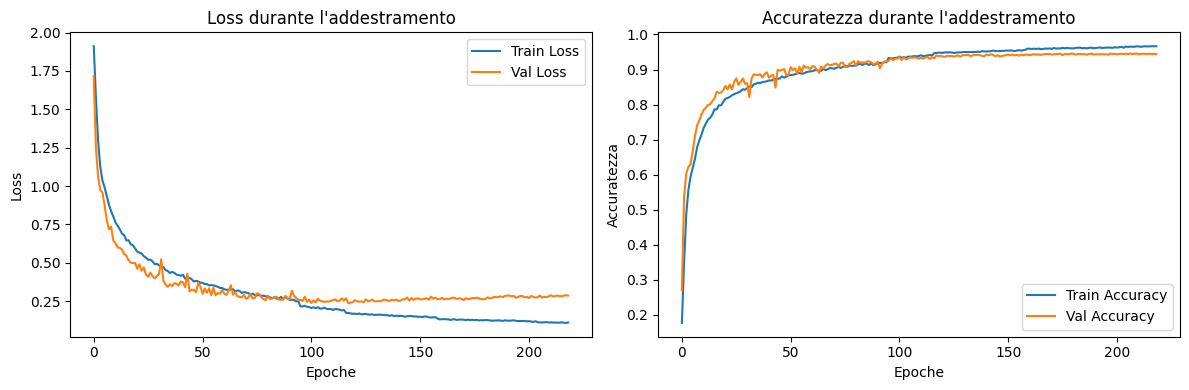

In [ ]:
# Valutazione sul Test Set
print("--- Valutazione sul Test Set ---")
test_loss, test_accuracy = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")


# Visualizzazione dei risultati
plt.figure(figsize=(12, 4))

# Plot della Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss durante l\'addestramento')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend()

# Plot dell'Accuratezza
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuratezza durante l\'addestramento')
plt.xlabel('Epoche')
plt.ylabel('Accuratezza')
plt.legend()

plt.tight_layout()
plt.show()

### Saving the Model

In [ ]:
model_dir_path_drive = '/content/drive/MyDrive/Project MLA - On Edge Motion Recognition/'

drive_models_dir = os.path.join(model_dir_path_drive, 'models')
os.makedirs(drive_models_dir, exist_ok=True)

# Define the file name
final_model_path = os.path.join(drive_models_dir, 'final_model_small.h5')
baseline_model.save(final_model_path)

print(f"Final model successfully saved in:\n{final_model_path}")

Modello finale salvato con successo in:
/content/drive/MyDrive/Project MLA - On Edge Motion Recognition/models/final_model_small.h5


## Quantization with QuantizeML

In [ ]:
# Loading the model with optimal weights
model_path_h5 = '/content/drive/MyDrive/Project MLA - On Edge Motion Recognition/models/best/FinalModel_small.h5'
baseline_model.load_weights(model_path_h5)
print(f"Float model weights loaded from: {model_path_h5}")

# Evaluation on the Test Set
print("\n--- Evaluation on the Test Set (baseline model) ---")
test_loss, test_accuracy = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

Pesi del modello float caricati da: /content/drive/MyDrive/Project MLA - On Edge Motion Recognition/models/best/FinalModel_small.h5

--- Valutazione sul Test Set (baseline model) ---
Test Loss: 0.2851
Test Accuracy: 94.55%


In [ ]:
num_calibration_samples = 2048
indices = np.random.choice(len(X_train), num_calibration_samples, replace=False)
calibration_data = X_train[indices]

qparams = QuantizationParams(
    input_weight_bits=8,
    weight_bits=4,
    activation_bits=4,
)

with set_akida_version(AkidaVersion.v1):
    quantized_model = quantize(
        baseline_model,
        qparams=qparams,
        samples=calibration_data
    )

print("\n--- Quantized Model Structure ---")
quantized_model.summary()

quantized_model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("\n--- Quantized Model Evaluation ---")
q_test_loss, q_test_accuracy = quantized_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (Quantized): {q_test_loss:.4f}")
print(f"Test Accuracy (Quantized): {q_test_accuracy*100:.2f}%")

1024/1024 [==============================] - 4s 4ms/step

--- Struttura del Modello Quantizzato ---
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 41, 9, 1)]        0         
                                                                 
 input_quantizer (InputQuan  (None, 41, 9, 1)          2         
 tizer)                                                          
                                                                 
 conv2d (QuantizedConv2D)    (None, 21, 5, 32)         320       
                                                                 
 re_lu (QuantizedReLU)       (None, 21, 5, 32)         64        
                                                                 
 conv2d_1 (QuantizedConv2D)  (None, 11, 3, 64)         18496     
                                                                 
 re_lu_1 (QuantizedReL

### Fine Tuning Quantized Model


In [ ]:
print("--- Quantized Model Fine-Tuning (QAT) Alignment Strategy ---")

# Google Drive path
qat_model_path = '/content/drive/MyDrive/Project MLA - On Edge Motion Recognition/models/final_model_small_quantized.h5'
os.makedirs(os.path.dirname(qat_model_path), exist_ok=True)

qat_checkpoint = ModelCheckpoint(
    filepath=qat_model_path,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

qat_early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Adaptive LR also for QAT (very useful to stabilize quantization)
qat_reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

# Initial learning rate
quantized_model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss=tf_keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Training
history_qat = quantized_model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[qat_checkpoint, qat_early_stopping, qat_reduce_lr]
)

print(f"Fine-tuning completed and best weights directly saved in: {qat_model_path}")


--- Fine-Tuning del Modello Quantizzato (QAT) Strategia Allineamento ---
Epoch 1/200
352/354 [============================>.] - ETA: 0s - loss: 1.8297 - accuracy: 0.4904
Epoch 1: val_accuracy improved from -inf to 0.53066, saving model to /content/drive/MyDrive/Project MLA - On Edge Motion Recognition/models/final_model_small_quantized.h5
354/354 [==============================] - 42s 51ms/step - loss: 1.8266 - accuracy: 0.4911 - val_loss: 1.2764 - val_accuracy: 0.5307 - lr: 5.0000e-04
Epoch 2/200
354/354 [==============================] - ETA: 0s - loss: 0.9976 - accuracy: 0.6378
Epoch 2: val_accuracy improved from 0.53066 to 0.70710, saving model to /content/drive/MyDrive/Project MLA - On Edge Motion Recognition/models/final_model_small_quantized.h5
354/354 [==============================] - 13s 36ms/step - loss: 0.9976 - accuracy: 0.6378 - val_loss: 0.8725 - val_accuracy: 0.7071 - lr: 5.0000e-04
Epoch 3/200
354/354 [==============================] - ETA: 0s - loss: 0.8922 - accurac

In [ ]:
# Evaluation on the Test Set
print("--- Evaluation on the Test Set ---")
test_loss, test_accuracy = quantized_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

In [ ]:
# Save the fine-tuned quantized model weights
qat_model_path = '/content/drive/MyDrive/Project MLA - On Edge Motion Recognition/models/final_model_small_quantized.h5'
quantized_model.save_weights(qat_model_path)
print(f"Fine-tuned weights saved successfully to: {qat_model_path}")

Fine-tuned weights saved successfully to: /content/drive/MyDrive/Project MLA - On Edge Motion Recognition/models/final_model_small_quantized.h5


## Convertion to Akida SNN and Evaluation

In [ ]:
# Load the best QAT weights into the quantized model
qat_model_path = '/content/drive/MyDrive/Project MLA - On Edge Motion Recognition/models/best/FinalModel_quantized_small.h5'
quantized_model.load_weights(qat_model_path)
print(f"QAT weights loaded from: {qat_model_path}")

# Verify that the weights are the correct ones
_, acc_check = quantized_model.evaluate(X_test, y_test, verbose=0)
print(f"Quantized accuracy with QAT weights (pre-conversion): {acc_check*100:.2f}%")

# Conversion
with set_akida_version(AkidaVersion.v1):
    akida_model = cnn2snn.convert(quantized_model)

print("Conversion completed.")

# Evaluation
preds = akida_model.predict(X_test)
akida_preds = np.argmax(preds, axis=-1).flatten()
akida_accuracy = np.mean(akida_preds == y_test)
print(f"\nAkida Accuracy: {akida_accuracy * 100:.2f}%")

# HW Mapping
device = akida.AKD1000()
akida_model.map(device=device)
akida_model.summary()

Pesi QAT caricati da: /content/drive/MyDrive/Project MLA - On Edge Motion Recognition/models/best/FinalModel_quantized_small.h5
Accuracy quantizzato con pesi QAT (pre-conversione): 91.18%
Conversione completata.

Accuratezza Akida: 91.41%
                                     Model Summary                                     
_______________________________________________________________________________________
Input shape  Output shape  Sequences  Layers  NPs  Skip DMAs  External Memory (Bytes)
[41, 9, 1]   [1, 1, 7]     2          8       63   0          0                      
_______________________________________________________________________________________

_________________________
Component (type)  Count
HRC               1    
_________________________
CNP1              60   
_________________________
FNP3              3    
_________________________

________________________________________________________________________
Layer (type)                 Output shape  Kernel 

In [ ]:
akida_fb_path = '/content/drive/MyDrive/Project MLA - On Edge Motion Recognition/models/best/FinalModel_quantized_akida_small.fb'
akida_model.save(akida_fb_path)

print(f"Akida SNN model saved successfully in .fb format: {akida_fb_path}")

Modello Akida SNN salvato correttamente in formato .fb: /content/drive/MyDrive/Project MLA - On Edge Motion Recognition/models/best/FinalModel_quantized_akida_small.fb
